Epochs: 100%|██████████| 4000/4000 [2:54:50<00:00,  2.62s/it, avg_loss=-3.21e+7]


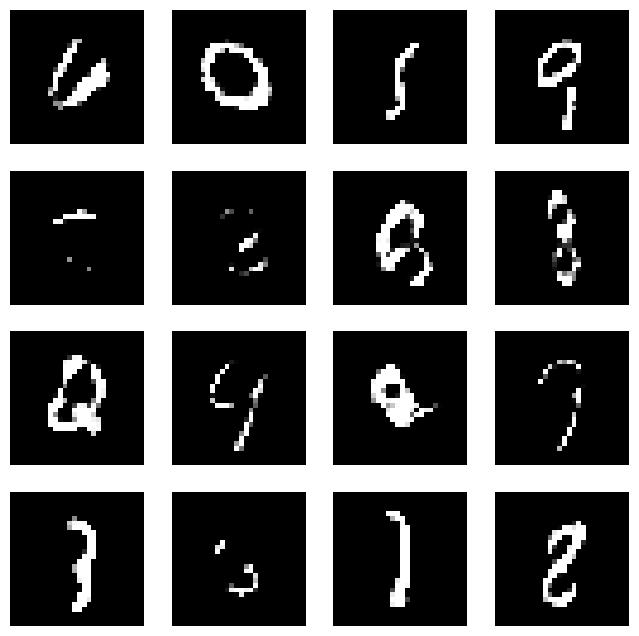

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Constants
LATENT_DIM = 10
INPUT_DIM = 28 * 28
HIDDEN_DIM = 512
BATCH_SIZE = 512
EPOCHS = 4000
LR = 1e-4

# Define VAE Model
class VAE(nn.Module):
    def __init__(self, latent_dim = 100):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(nn.Linear(784, 400),
                                     nn.BatchNorm1d(400),
                                     nn.ReLU()
                                     )
                                     
                                     
        self.enc_log_sigma = nn.Linear(400, self.latent_dim)
        self.enc_mu = nn.Linear(400, self.latent_dim)
        
        self.decoder = nn.Sequential(nn.Linear(self.latent_dim, 400),
                                     nn.BatchNorm1d(400),
                                     nn.ReLU(),
                                     nn.Linear(400,784),
                                     nn.Sigmoid()
                                     )

    def encode(self, x):
        h1 = self.encoder(x)
        return self.enc_mu(h1), self.enc_log_sigma(h1)
        
    def sample_latent(self, mu, log_sigma):
        sigma = torch.exp(0.5*log_sigma)
        
        eps = torch.Tensor(sigma.shape).normal_()
        if torch.cuda.is_available():
            eps = eps.cuda()
        
        return eps.mul(sigma).add_(mu)
        
    def forward(self, input):
        mu, logvar = self.encode(input)
        
        z = self.sample_latent(mu, logvar)
        return self.decoder(z), mu, logvar



def get_dataloader(batch_size, pad=False):
    if pad:
        transform = transforms.Compose([
                transforms.Pad(padding = 2, padding_mode = 'edge'),
                transforms.ToTensor()
                ])
    else:
        transform = transforms.ToTensor()
    
    dataset = datasets.MNIST(root = '../data', train = True, download = True, 
                    transform = transform)
    dataloader = DataLoader(dataset = dataset, batch_size = batch_size, 
                            shuffle = True)
    return dataloader



def makedirs(sample_dir, checkpoint_dir):
    if not os.path.exists(sample_dir):
        os.makedirs(sample_dir)
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)



def kl_div(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

epochs = 100
batch_size = 100
latent_dim = 2
dataloader = utils.get_dataloader(batch_size)
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
step_per_epoch = np.ceil(dataloader.dataset.__len__() / batch_size)


sample_dir = '../data/mnist/vae/wgsamples'
checkpoint_dir = '../data/mnist/vae/checkpoints'

makedirs(sample_dir, checkpoint_dir)

net = VAE(latent_dim = latent_dim).to(device)
optim = torch.optim.Adam(net.parameters())

rec_log = []
kl_log = []

criterion = nn.BCELoss(reduction = 'sum')

result = None
for epoch_i in range(1, epochs + 1):
    for step_i, (real_img, _) in enumerate(dataloader):
        N = real_img.shape[0]
        real_img = real_img.view(N, -1).to(device)
        
        if result is None:
            result = real_img
            
        reconstructed, mu, logvar = net(real_img)
        
        reconstruction_loss = criterion(reconstructed, real_img)
        kl_loss = kl_div(mu, logvar)
        
        loss = kl_loss + reconstruction_loss
        
        optim.zero_grad()
        loss.backward()
        optim.step()
        
        rec_log.append(reconstruction_loss.item())
        kl_log.append(kl_loss.item())
        

# Save the final generator and discriminator models
torch.save(G.state_dict(), f"{checkpoint_dir}/vae_final.pth")

steps = 50
z = utils.box_muller(steps).to(device)
result = net.decoder(z)
torchvision.utils.save_image(result.reshape(-1, 1, 28, 28), 
                             os.path.join(sample_dir, 'manifold.png'), 
                             nrow = steps)


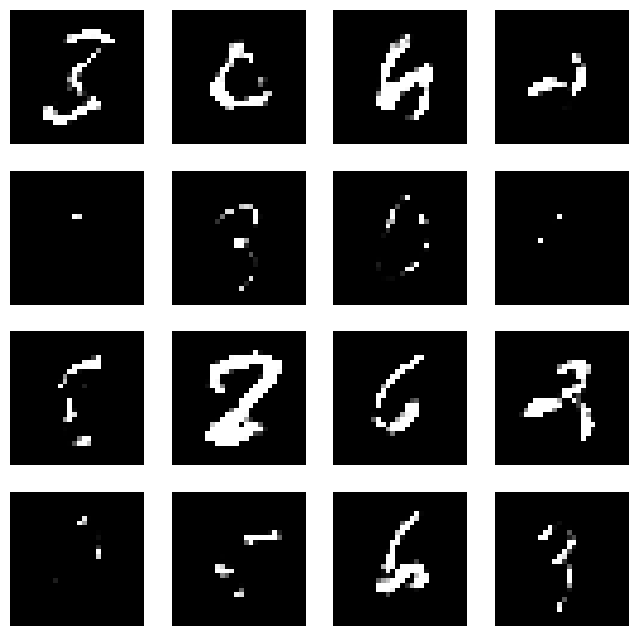

In [8]:
# Generate Samples
def generate_samples_():
    vae.eval()
    with torch.no_grad():
        z = torch.randn(16, LATENT_DIM).to(device) + 0.2
        samples = vae.decode(z).cpu().view(-1, 28, 28)

        fig, axs = plt.subplots(4, 4, figsize=(8, 8))
        for i, ax in enumerate(axs.flatten()):
            ax.imshow(samples[i], cmap="gray")
            ax.axis("off")
        plt.show()
generate_samples_()

In [10]:
# Save model weights
torch.save(vae.state_dict(), f"../data/VAE-MNIST/model.pth")